# Crude Oil Futures (CL) -- Regime prediction using GARCH Volatility Prediction model

**Objective:** Predict Crude Oil regime based on predicted volatility of WTI Crude Oil futures using GARCH-family models.

**Stages:**
1. Data collection from QuantConnect
2. Exploratory data analysis (returns, rolling means, KDE, realized volatility)
3. GARCH parameter exploration (ACF/PACF, distribution selection)
4. Build model with train/test split
5. Evaluate performance on test data
6. Performance metrics
7. Separate timeline into regimes.

---
## Stage 1 -- Data Collection from QuantConnect

In [63]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import jarque_bera, shapiro

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf, adfuller
from arch import arch_model

# QuantConnect imports
from QuantConnect.Research import *
from QuantConnect import *

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

In [66]:
# Initialize QuantBook and fetch daily CL futures data
qb = QuantBook()

future = qb.AddFuture(Futures.Energies.CrudeOilWTI,
                      Resolution.Daily,
                      extendedMarketHours=False)
future.SetFilter(0, 90)

# Pull daily history 10 years for robust GARCH estimation
history = qb.History(future.Symbol,
                     start=pd.Timestamp("2015-01-01"),
                     end=pd.Timestamp("2026-03-15"),
                     resolution=Resolution.Daily)

# Build clean OHLCV dataframe
df = history.reset_index()
df = df[['time', 'open', 'high', 'low', 'close', 'volume']]
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time')
df = df[~df.index.duplicated(keep='first')]
df = df.sort_index()
df.dropna(inplace=True)

print(f"Date range: {df.index[0].date()} -> {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")
df.tail()

Date range: 2015-01-02 -> 2026-03-13
Total trading days: 2826


,open,high,low,close,volume
time,,,,,
2026-03-09 17:00:00,98.329934,102.669608,79.714502,83.533807,362419.0
2026-03-10 17:00:00,87.176384,87.500387,75.335555,84.820000,359481.0
2026-03-11 17:00:00,84.340000,87.290000,81.050000,87.070000,108360.0
2026-03-12 17:00:00,92.870000,95.680000,91.520000,95.080000,120490.0
2026-03-13 17:00:00,92.480000,97.310000,92.030000,97.200000,76561.0


---
## Stage 2 -- Exploratory Data Analysis

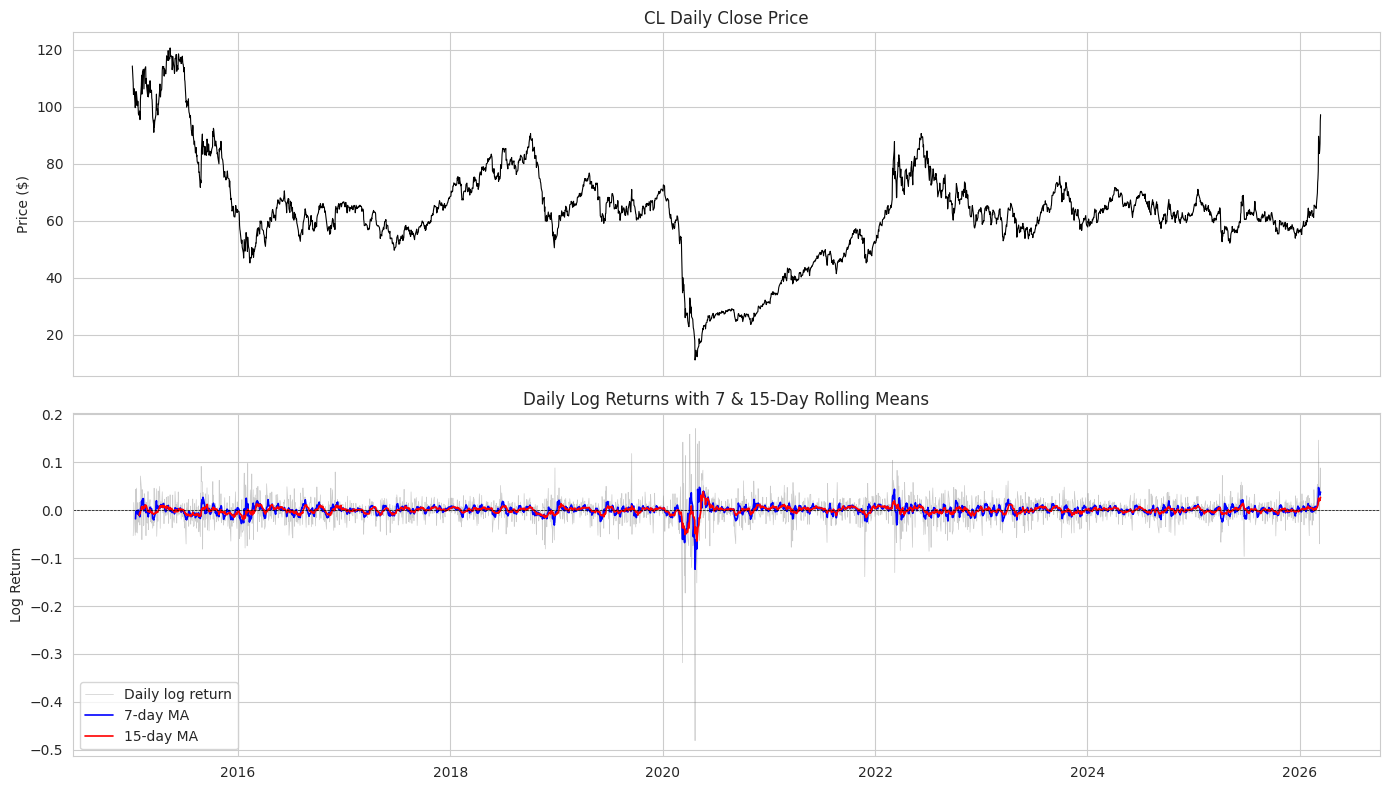


=== Return Summary Statistics ===
count    2825.000000
mean       -0.000057
std         0.027570
min        -0.480806
25%        -0.012620
50%         0.001046
75%         0.013480
max         0.170184
Name: log_return, dtype: float64

Skewness:  -2.4297
Kurtosis:  42.9308


In [67]:
# 2a) Log returns & rolling mean returns (7-day and 15-day)
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['return_ma7'] = df['log_return'].rolling(7).mean()
df['return_ma15'] = df['log_return'].rolling(15).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price plot
axes[0].plot(df.index, df['close'], color='black', linewidth=0.8)
axes[0].set_title('CL Daily Close Price')
axes[0].set_ylabel('Price ($)')

# Returns with rolling means
axes[1].plot(df.index, df['log_return'], alpha=0.4, linewidth=0.5, label='Daily log return', color='grey')
axes[1].plot(df.index, df['return_ma7'], linewidth=1.2, label='7-day MA', color='blue')
axes[1].plot(df.index, df['return_ma15'], linewidth=1.2, label='15-day MA', color='red')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('Daily Log Returns with 7 & 15-Day Rolling Means')
axes[1].set_ylabel('Log Return')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Return Summary Statistics ===")
print(df['log_return'].describe())
print(f"\nSkewness:  {df['log_return'].skew():.4f}")
print(f"Kurtosis:  {df['log_return'].kurtosis():.4f}")

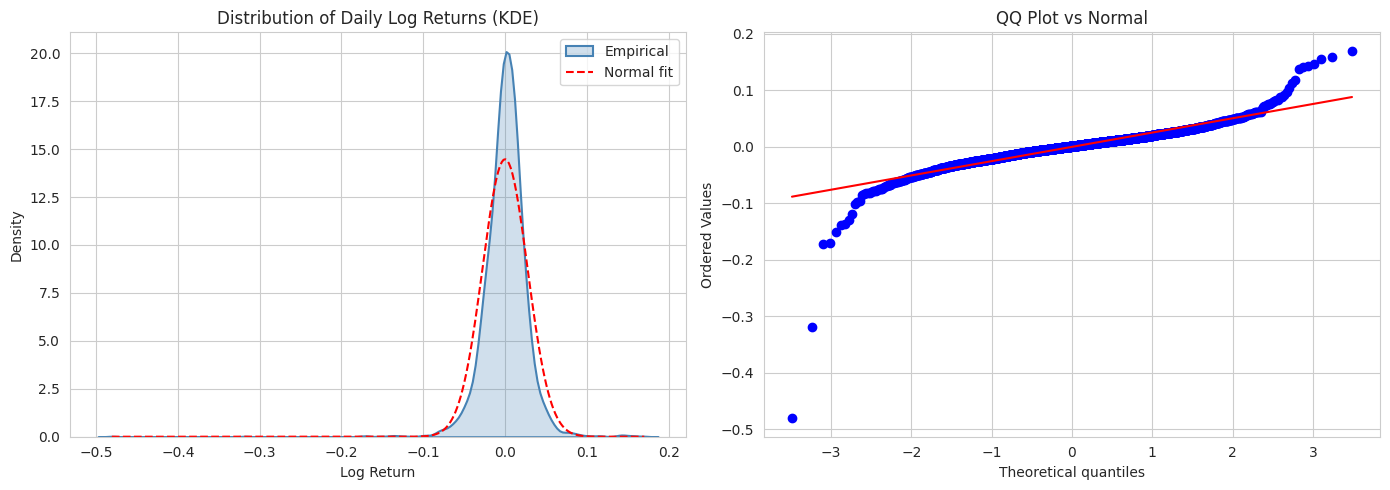

Jarque-Bera test: stat=218930.74, p-value=0.000000
  -> Reject normality at 5% level
Shapiro-Wilk test: stat=0.8443, p-value=0.000000


In [68]:
# 2b) Distribution of returns -- KDE plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns = df['log_return'].dropna()

# KDE plot
sns.kdeplot(returns, ax=axes[0], fill=True, color='steelblue', linewidth=1.5, label='Empirical')

# Overlay normal distribution for comparison
x = np.linspace(returns.min(), returns.max(), 300)
axes[0].plot(x, stats.norm.pdf(x, returns.mean(), returns.std()),
             'r--', linewidth=1.5, label='Normal fit')
axes[0].set_title('Distribution of Daily Log Returns (KDE)')
axes[0].set_xlabel('Log Return')
axes[0].legend()

# QQ plot
stats.probplot(returns, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot vs Normal')

plt.tight_layout()
plt.show()

# Normality tests
jb_stat, jb_pval = jarque_bera(returns)
print(f"Jarque-Bera test: stat={jb_stat:.2f}, p-value={jb_pval:.6f}")
print(f"  -> {'Reject' if jb_pval < 0.05 else 'Fail to reject'} normality at 5% level")

if len(returns) <= 5000:
    sw_stat, sw_pval = shapiro(returns[:5000])
    print(f"Shapiro-Wilk test: stat={sw_stat:.4f}, p-value={sw_pval:.6f}")

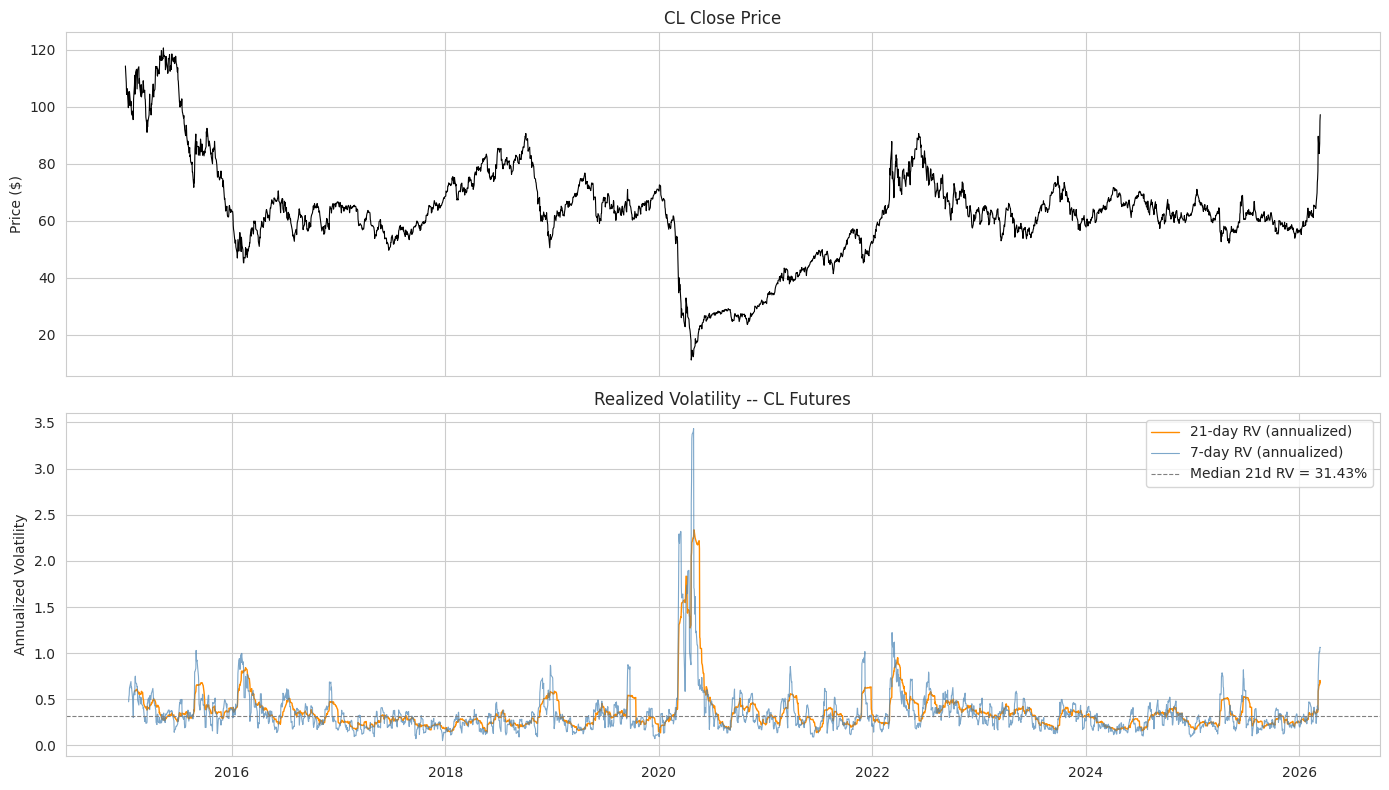

21-day RV -- mean: 0.36, median: 0.31, max: 2.3


In [69]:
# 2c) Realized volatility (rolling 21-day annualized)
df['realized_vol_21'] = df['log_return'].rolling(21).std() * np.sqrt(252)
df['realized_vol_7'] = df['log_return'].rolling(7).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['close'], color='black', linewidth=0.8)
axes[0].set_title('CL Close Price')
axes[0].set_ylabel('Price ($)')

axes[1].plot(df.index, df['realized_vol_21'], label='21-day RV (annualized)', color='darkorange', linewidth=1)
axes[1].plot(df.index, df['realized_vol_7'], label='7-day RV (annualized)', color='steelblue', linewidth=0.8, alpha=0.7)
axes[1].axhline(df['realized_vol_21'].median(), color='grey', linestyle='--', linewidth=0.8, label=f"Median 21d RV = {df['realized_vol_21'].median():.2%}")
axes[1].set_title('Realized Volatility -- CL Futures')
axes[1].set_ylabel('Annualized Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"21-day RV -- mean: {df['realized_vol_21'].mean():.2}, median: {df['realized_vol_21'].median():.2}, max: {df['realized_vol_21'].max():.2}")

---
## Stage 3 -- GARCH Parameter Exploration

Key diagnostics:
- **ADF test** on returns to confirm stationarity
- **ACF/PACF of squared returns** to detect ARCH effects and choose p, q
- **Ljung-Box test** on squared returns for serial correlation
- **ARCH LM test** for conditional heteroskedasticity
- Compare error distributions: Normal, Student-t, Skewed Student-t

In [70]:
# 3a) Stationarity test on returns
returns = df['log_return'].dropna()

adf_result = adfuller(returns)
print("=== Augmented Dickey-Fuller Test on Log Returns ===")
print(f"ADF Statistic:  {adf_result[0]:.4f}")
print(f"p-value:        {adf_result[1]:.6f}")
print(f"Lags used:      {adf_result[2]}")
print(f"Observations:   {adf_result[3]}")
for key, val in adf_result[4].items():
    print(f"  Critical ({key}): {val:.4f}")
print("\n")
print(f"Returns are {'stationary' if adf_result[1] < 0.05 else 'NOT stationary'} at 5% level")

=== Augmented Dickey-Fuller Test on Log Returns ===
ADF Statistic:  -9.2439
p-value:        0.000000
Lags used:      25
Observations:   2799
  Critical (1%): -3.4327
  Critical (5%): -2.8626
  Critical (10%): -2.5673


Returns are stationary at 5% level


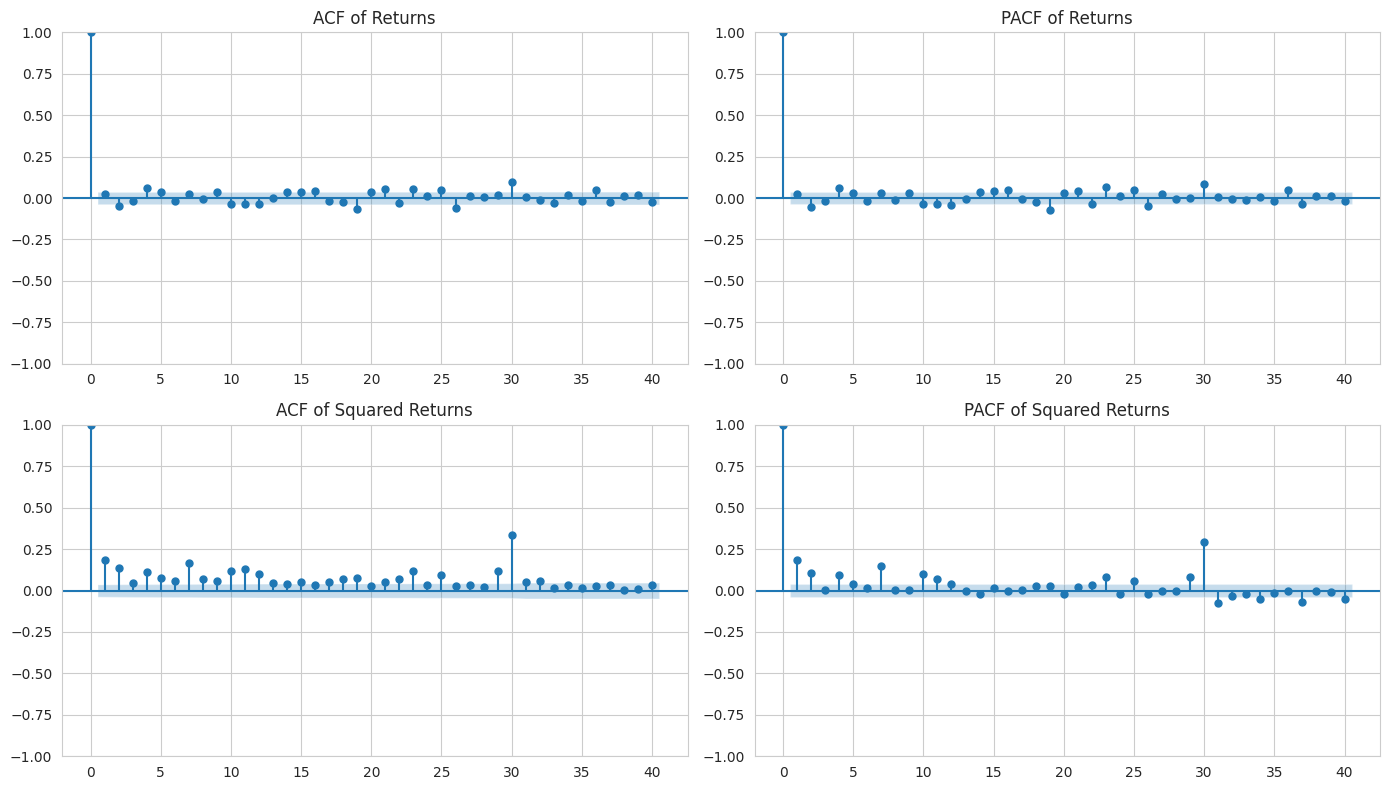

In [71]:
# 3b) ACF/PACF of squared returns -- detect ARCH effects and choose p, q
squared_returns = returns ** 2

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(returns, lags=40, ax=axes[0, 0], title='ACF of Returns')
plot_pacf(returns, lags=40, ax=axes[0, 1], title='PACF of Returns')
plot_acf(squared_returns, lags=40, ax=axes[1, 0], title='ACF of Squared Returns')
plot_pacf(squared_returns, lags=40, ax=axes[1, 1], title='PACF of Squared Returns')

plt.tight_layout()
plt.show()


## PACF Analysis 
Squared returns showed auto correlation at 1-2 lags. and some correlation at 30 (might be related to future rotation?)

So use q term as 1 - Today's volatility is correlated with yesterday's volatility. Use residuals to traing the model.

Use last sigma term, which means p = 1



In [72]:
# 3c) ARCH LM test and Ljung-Box test on squared returns
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Ljung-Box test on squared returns
lb_result = acorr_ljungbox(squared_returns, lags=[10, 20, 30], return_df=True)
print("=== Ljung-Box Test on Squared Returns ===")
print(lb_result)
print(f"Significant p-values confirm serial correlation in variance (ARCH effects)\n")

# ARCH LM test
arch_lm = het_arch(returns, nlags=10)
print("=== Engle's ARCH LM Test ===")
print(f"LM Statistic: {arch_lm[0]:.4f}")
print(f"p-value:      {arch_lm[1]:.6f}")
print(f"F-Statistic:  {arch_lm[2]:.4f}")
print(f"F p-value:    {arch_lm[3]:.6f}")
print(f"{'ARCH effects present' if arch_lm[1] < 0.05 else 'No ARCH effects'} -- GARCH modeling is {'justified' if arch_lm[1] < 0.05 else 'questionable'}")

=== Ljung-Box Test on Squared Returns ===
       lb_stat      lb_pvalue
10  352.961292   9.373575e-70
20  489.390028   4.834746e-91
30  947.513646  6.031050e-180
Significant p-values confirm serial correlation in variance (ARCH effects)

=== Engle's ARCH LM Test ===
LM Statistic: 237.7861
p-value:      0.000000
F-Statistic:  25.8710
F p-value:    0.000000
ARCH effects present -- GARCH modeling is justified



## Analysis 
Ljung-Box null hypothesis: Data is independently distributed(no auto correlation)
<br>
Ljung-Box results how low P-Value means, we reject the null hypothesis means, squared returns are not white noise and contains information



In [ ]:
# 3d) Model selection -- compare GARCH variants via AIC/BIC
# Scale returns to percentage for numerical stability (arch library convention)
returns_pct = returns * 100

model_configs = [
    ('GARCH(1,1) Normal',    {'vol': 'GARCH', 'p': 1, 'q': 1, 'dist': 'normal'}),
    ('GARCH(1,1) Student-t', {'vol': 'GARCH', 'p': 1, 'q': 1, 'dist': 'studentst'}),
    ('GARCH(1,1) Skew-t',    {'vol': 'GARCH', 'p': 1, 'q': 1, 'dist': 'skewt'}),
    ('GARCH(2,1) Student-t', {'vol': 'GARCH', 'p': 2, 'q': 1, 'dist': 'studentst'}),
    ('GARCH(1,2) Student-t', {'vol': 'GARCH', 'p': 1, 'q': 2, 'dist': 'studentst'}),
    ('EGARCH(1,1) Student-t', {'vol': 'EGARCH', 'p': 1, 'q': 1, 'dist': 'studentst'}),
    ('GJR-GARCH(1,1) Student-t', {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'studentst'}),
]

results = []
for name, cfg in model_configs:
    dist = cfg.pop('dist')
    try:
        am = arch_model(returns_pct, mean='Constant', dist=dist, **cfg)
        res = am.fit(disp='off')
        results.append({'Model': name, 'AIC': res.aic, 'BIC': res.bic, 'LogLik': res.loglikelihood})
    except Exception as e:
        results.append({'Model': name, 'AIC': np.nan, 'BIC': np.nan, 'LogLik': np.nan})

results_df = pd.DataFrame(results).sort_values('BIC')
print("=== Model Comparison (sorted by BIC) ===")
print(results_df.to_string(index=False))
print("\n")
print(f"Best model by BIC: {results_df.iloc[0]['Model']}")

=== Model Comparison (sorted by BIC) ===
                   Model          AIC          BIC       LogLik
       GARCH(1,1) Skew-t 12383.722223 12419.399805 -6185.861111
GJR-GARCH(1,1) Student-t 12397.941746 12433.619328 -6192.970873
    GARCH(1,1) Student-t 12404.290798 12434.022116 -6197.145399
   EGARCH(1,1) Student-t 12411.886608 12441.617927 -6200.943304
    GARCH(2,1) Student-t 12406.118432 12441.796014 -6197.059216
    GARCH(1,2) Student-t 12406.290798 12441.968380 -6197.145399
       GARCH(1,1) Normal 12554.021612 12577.806666 -6273.010806


Best model by BIC: GARCH(1,1) Skew-t


---
## Stage 4 -- Build GARCH Model (Train / Test Split)

Using the best model from Stage 3. Train on ~80% of data, hold out the last ~20% for rolling one-step-ahead forecasts.

In [ ]:
# 4a) Train/test split and fit GARCH model on training data
split_ratio = 0.80
split_idx = int(len(returns_pct) * split_ratio)

train = returns_pct.iloc[:split_idx]
test = returns_pct.iloc[split_idx:]

print(f"Training: {train.index[0].date()} -> {train.index[-1].date()} ({len(train)} days)")
print(f"Test:     {test.index[0].date()} -> {test.index[-1].date()} ({len(test)} days)")

# Best model is GARCH(1, 1)-skewt
am_train = arch_model(train, mean='Constant', vol='GARCH', p=1, q=1, dist='skewt')
res_train = am_train.fit(disp='off')
print(res_train.summary())

Training: 2015-01-05 → 2023-12-22 (2260 days)
Test:     2023-12-26 → 2026-03-13 (565 days)
                           Constant Mean - GARCH Model Results                           
Dep. Variable:                        log_return   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -5034.38
Distribution:      Standardized Skew Student's t   AIC:                           10080.8
Method:                       Maximum Likelihood   BIC:                           10115.1
                                                   No. Observations:                 2260
Date:                           Sun, Mar 15 2026   Df Residuals:                     2259
Time:                                   22:03:03   Df Model:                            1
                                 Mean Model                                
                 coef  

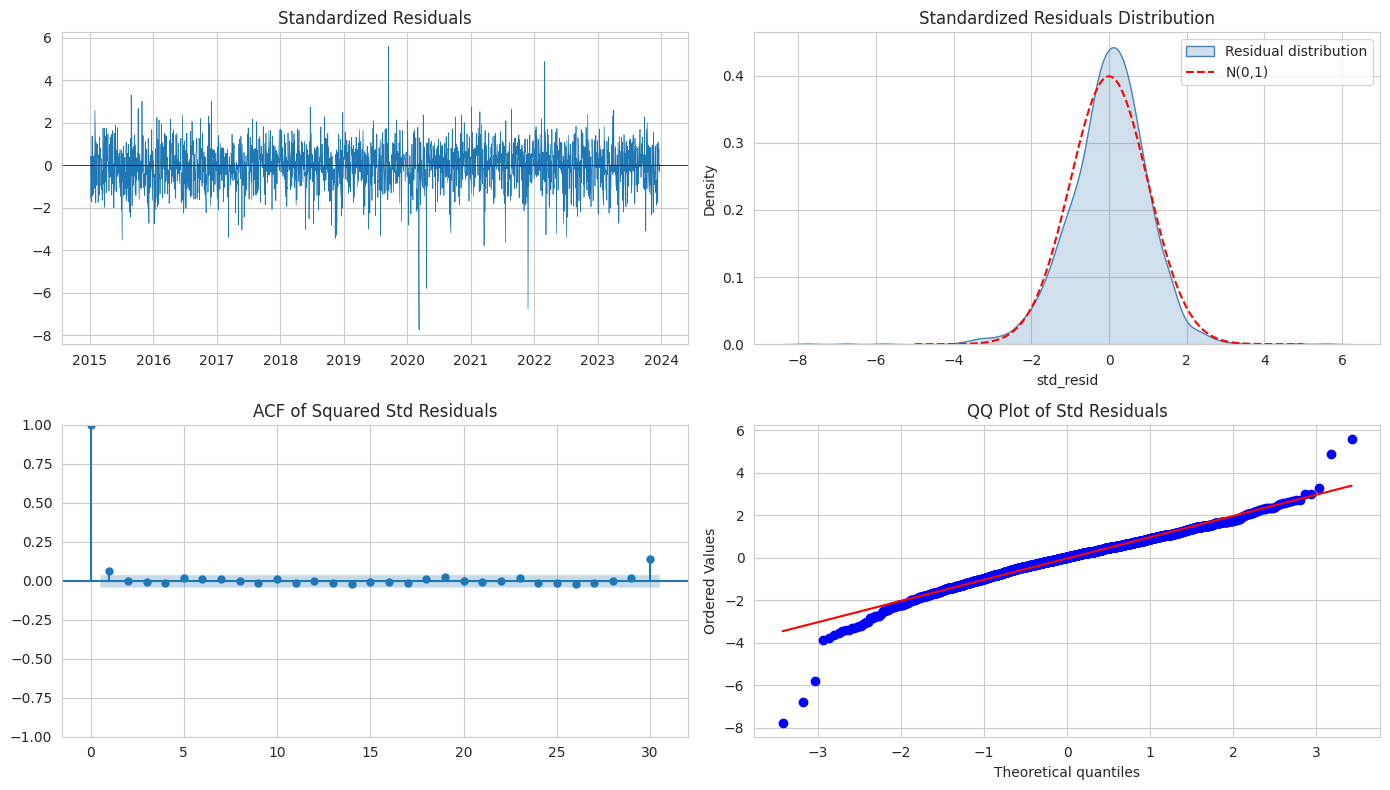

Ljung-Box on squared standardized residuals:
      lb_stat  lb_pvalue
10  11.675211   0.307381
20  15.638080   0.738808


Model captured ARCH effects adequately


In [39]:
# 4b) Standardized residual diagnostics on training fit
std_resid = res_train.std_resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Standardized residuals time series
axes[0, 0].plot(std_resid, linewidth=0.5)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].axhline(0, color='black', linewidth=0.5)

# Distribution of standardized residuals
sns.kdeplot(std_resid, ax=axes[0, 1], fill=True, color='steelblue', label='Residual distribution')
x = np.linspace(-5, 5, 300)
axes[0, 1].plot(x, stats.norm.pdf(x), 'r--', label='N(0,1)')
axes[0, 1].set_title('Standardized Residuals Distribution')
axes[0, 1].legend()

# ACF of squared standardized residuals (should be white noise if model is adequate)
plot_acf(std_resid ** 2, lags=30, ax=axes[1, 0], title='ACF of Squared Std Residuals')

# QQ plot
stats.probplot(std_resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot of Std Residuals')

plt.tight_layout()
plt.show()

# Ljung-Box on squared standardized residuals
lb_resid = acorr_ljungbox(std_resid ** 2, lags=[10, 20], return_df=True)
print("Ljung-Box on squared standardized residuals:")
print(lb_resid)
print("\n")
if lb_resid.iloc[0]['lb_pvalue'] > 0.05:     
    print("Model captured ARCH effects adequately")
else:
    print("Model *did* not cpature ARCH effects")


In [47]:
# Forecast next day variance
forecast_1 = res_train.forecast(horizon=1)
forecast_1.variance

,h.1
time,
2023-12-22 17:00:00,3.516622



## Analysis 
Ljung-Box null hypothesis: Data is independently distributed(no auto correlation)
<br>
Ljung-Box results in values > 0.05 (0.3), we accept the null hypothesis means, residuals are independently distributed, we extracted information.



---
## Stage 5 -- Test Data Performance (Rolling Forecast)

Expanding-window, one-step-ahead volatility forecasts on test period. Each day we re-estimate using all available data up to that point, then forecast one day ahead.

In [ ]:
# 5a) Rolling one-step-ahead volatility forecast on test set
forecasts = {}

for i in range(len(test)):
    # Expanding window: all data up to current test point
    train_window = returns_pct.iloc[:split_idx + i]
    
    am = arch_model(train_window, mean='Constant', vol='GARCH', p=1,q=1, dist='skewt')
    res = am.fit(disp='off', last_obs=len(train_window))
    
    # One-step-ahead forecast
    fcast = res.forecast(horizon=1)
    # Conditional variance -> daily vol in % terms
    forecasts[test.index[i]] = np.sqrt(fcast.variance.values[-1, 0])

forecast_vol = pd.Series(forecasts, name='forecast_vol_pct')

# Realized daily vol (absolute return as proxy, in % terms)
realized_daily_vol = test.abs()
realized_daily_vol.name = 'realized_vol_pct'

print(f"Forecast period: {forecast_vol.index[0].date()} -> {forecast_vol.index[-1].date()}")
print(f"Forecast days: {len(forecast_vol)}")

Forecast period: 2023-12-26 → 2026-03-13
Forecast days: 565


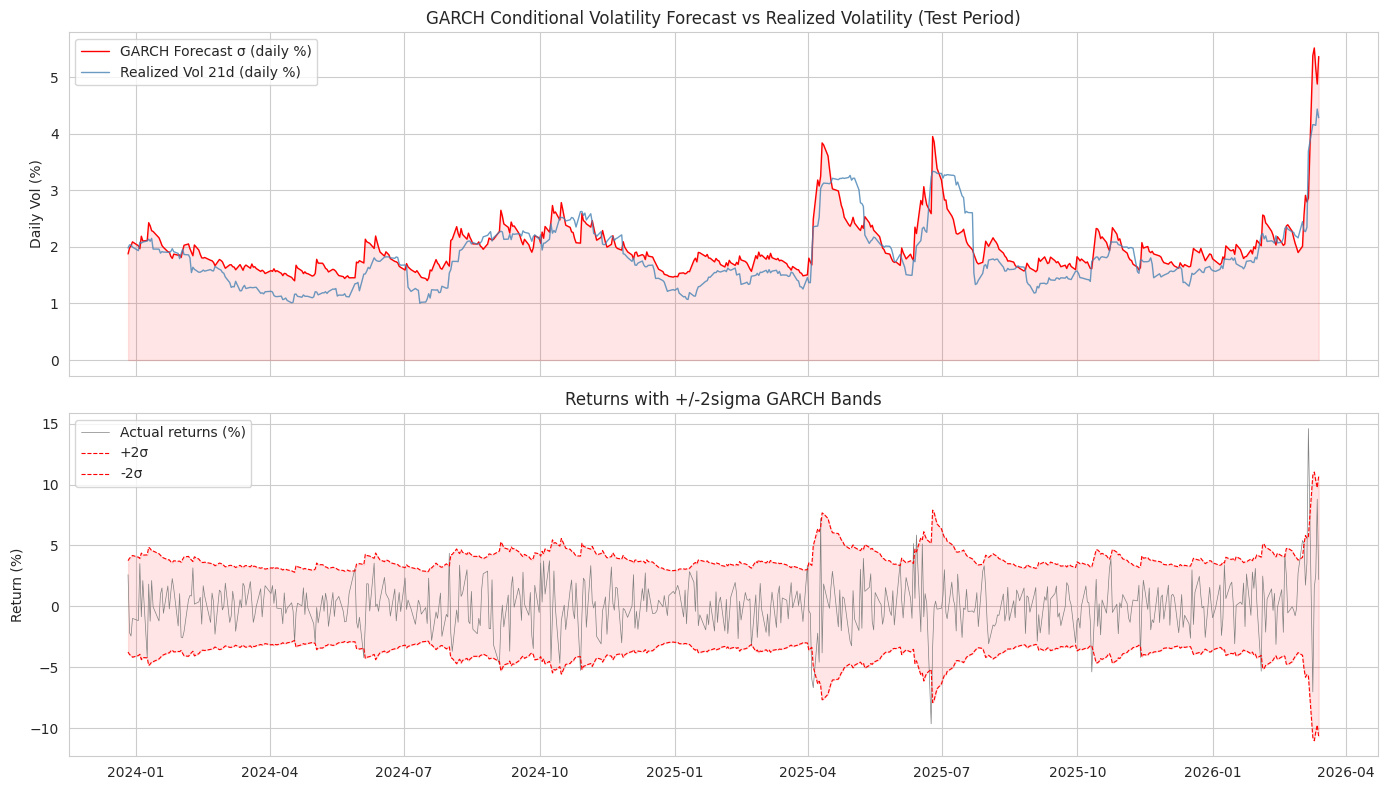

VaR exceedances (|return| > 2σ): 22 / 565 = 3.89% (expected ~5%)


In [ ]:
# 5b) Plot forecast vs realized volatility
# Use rolling 21-day realized vol in test period for smoother comparison
rv_21_test = df['realized_vol_21'].loc[test.index] * 100 / np.sqrt(252)  # daily, in %

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Forecast vs realized (rolling)
axes[0].plot(forecast_vol.index, forecast_vol.values, label='GARCH Forecast sigma (daily %)', color='red', linewidth=1)
axes[0].plot(rv_21_test.index, rv_21_test.values, label='Realized Vol 21d (daily %)', color='steelblue', linewidth=1, alpha=0.8)
axes[0].fill_between(forecast_vol.index, 0, forecast_vol.values, alpha=0.1, color='red')
axes[0].set_title('GARCH Conditional Volatility Forecast vs Realized Volatility (Test Period)')
axes[0].set_ylabel('Daily Vol (%)')
axes[0].legend()

# Actual returns with +/-2sigma bands
axes[1].plot(test.index, test.values, linewidth=0.5, color='grey', label='Actual returns (%)')
axes[1].plot(forecast_vol.index, 2 * forecast_vol.values, 'r--', linewidth=0.8, label='+2sigma')
axes[1].plot(forecast_vol.index, -2 * forecast_vol.values, 'r--', linewidth=0.8, label='-2sigma')
axes[1].fill_between(forecast_vol.index, -2 * forecast_vol.values, 2 * forecast_vol.values, alpha=0.1, color='red')
axes[1].set_title('Returns with +/-2sigma GARCH Bands')
axes[1].set_ylabel('Return (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# VaR exceedance check at 95%
exceedances = (test.abs() > 2 * forecast_vol).sum()
print(f"VaR exceedances (|return| > 2sigma): {exceedances} / {len(test)} = {exceedances/len(test):.2%} (expected ~5%)")

---
## Stage 6 -- Model Performance Metrics

**Metrics:**
- **MSE / RMSE / MAE** -- Forecast error vs realized proxy
- **QLIKE** -- Quasi-likelihood loss (asymmetric, penalizes under-prediction more)
- **Mincer-Zarnowitz regression** -- Regress realized vol on forecast; ideal: alpha=0, beta=1
- **Directional accuracy** -- Does the model correctly predict vol increasing/decreasing?

In [ ]:
# 6a) Core performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Align forecast variance with realized variance proxy (squared return)
forecast_var = forecast_vol ** 2       # forecast daily variance (%)
realized_var = test ** 2               # realized daily variance proxy (%)

# MSE, RMSE, MAE on variance
mse = mean_squared_error(realized_var, forecast_var)
rmse = np.sqrt(mse)
mae = mean_absolute_error(realized_var, forecast_var)

# QLIKE loss: mean( realized/forecast + log(forecast) ) -- lower is better
# Avoid division by zero
qlike = np.mean(realized_var / forecast_var - np.log(realized_var / forecast_var) - 1)

# R^2 (variance level)
ss_res = np.sum((realized_var - forecast_var) ** 2)
ss_tot = np.sum((realized_var - realized_var.mean()) ** 2)
r2_var = 1 - ss_res / ss_tot

print("=== Volatility Forecast Performance (Test Period) ===\n")
print(f"{'MSE (variance):':<25} {mse:.6f}")
print(f"{'RMSE (variance):':<25} {rmse:.6f}")
print(f"{'MAE (variance):':<25} {mae:.6f}")
print(f"{'QLIKE loss:':<25} {qlike:.6f}")
print(f"{'R^2 (variance):':<25} {r2_var:.4f}")

=== Volatility Forecast Performance (Test Period) ===

MSE (variance):           129.174861
RMSE (variance):          11.365512
MAE (variance):           4.413691
QLIKE loss:               inf
R² (variance):            0.0618


=== Mincer-Zarnowitz Regression ===
α (intercept): -0.109102  (p=0.8972)
β (slope):     1.003531  (p=0.0000)
R²:            0.0619

→ Joint test H₀: α=0, β=1:
   (Check: β close to 1 indicates good calibration)


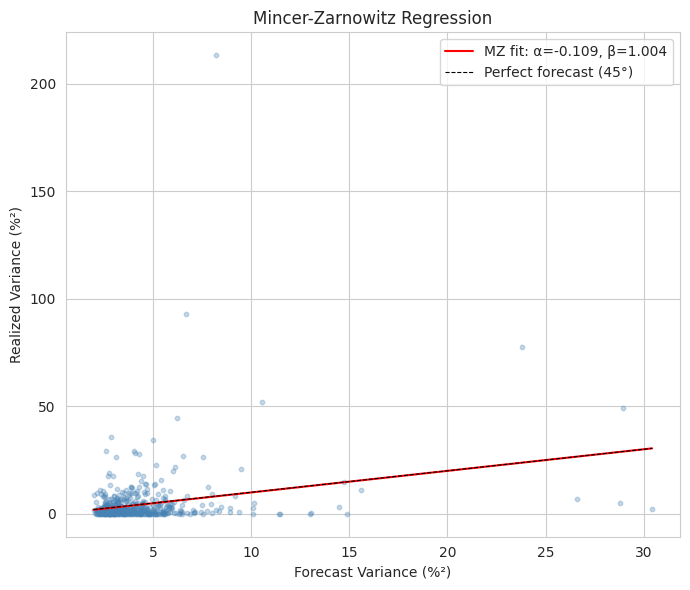

In [ ]:
# 6b) Mincer-Zarnowitz regression: realized_var = alpha + beta * forecast_var + e
#     Ideal: alpha=0, beta=1 (unbiased, well-calibrated forecast)
import statsmodels.api as sm

X = sm.add_constant(forecast_var.values)
y = realized_var.values

mz_model = sm.OLS(y, X).fit()

print("=== Mincer-Zarnowitz Regression ===")
print(f"alpha (intercept): {mz_model.params[0]:.6f}  (p={mz_model.pvalues[0]:.4f})")
print(f"beta (slope):      {mz_model.params[1]:.6f}  (p={mz_model.pvalues[1]:.4f})")
print(f"R^2:               {mz_model.rsquared:.4f}")
print(f"\n-> Joint test H0: alpha=0, beta=1:")
f_test = mz_model.f_test("x1=0, const=0")  # test alpha=0 jointly
print(f"   (Check: beta close to 1 indicates good calibration)")

# Scatter
plt.figure(figsize=(7, 6))
plt.scatter(forecast_var, realized_var, alpha=0.3, s=10, color='steelblue')
x_line = np.linspace(forecast_var.min(), forecast_var.max(), 100)
plt.plot(x_line, mz_model.params[0] + mz_model.params[1] * x_line, 'r-', label=f'MZ fit: a={mz_model.params[0]:.3f}, b={mz_model.params[1]:.3f}')
plt.plot(x_line, x_line, 'k--', linewidth=0.8, label='Perfect forecast (45 deg)')
plt.xlabel('Forecast Variance (%^2)')
plt.ylabel('Realized Variance (%^2)')
plt.title('Mincer-Zarnowitz Regression')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 6c) Directional accuracy -- does forecast correctly predict vol rising/falling?

forecast_var = forecast_vol ** 2       # forecast daily variance (%)
realized_var = test ** 2               # realized daily variance proxy (%)

forecast_direction = np.sign(forecast_var.diff().dropna())
realized_direction = np.sign(realized_var.diff().dropna())

# Align indices
common_idx = forecast_direction.index.intersection(realized_direction.index)
dir_accuracy = (forecast_direction.loc[common_idx] == realized_direction.loc[common_idx]).mean()

print(f"=== Directional Accuracy ===")
print(f"Correct direction: {dir_accuracy:.2%} ({int(dir_accuracy * len(common_idx))} / {len(common_idx)} days)")
print(f"(50% = random, >55% is useful for trading)\n")


=== Directional Accuracy ===
Correct direction: 28.72% (162 / 564 days)
(50% = random, >55% is useful for trading)



In [ ]:

# Summary table
print("=" * 55)
print("        GARCH MODEL PERFORMANCE SUMMARY")
print("=" * 55)
metrics_summary = pd.DataFrame({
    'Metric': ['MSE (variance)', 'RMSE (variance)', 'MAE (variance)', 
               'QLIKE Loss', 'R^2 (variance)', 'MZ alpha (intercept)', 'MZ beta (slope)', 
               'MZ R^2', 'Directional Accuracy', 'VaR Exceedance Rate'],
    'Value': [f"{mse:.6f}", f"{rmse:.6f}", f"{mae:.6f}",
              f"{qlike:.6f}", f"{r2_var:.4f}", f"{mz_model.params[0]:.6f}", f"{mz_model.params[1]:.4f}",
              f"{mz_model.rsquared:.4f}", f"{dir_accuracy:.2%}", f"{exceedances/len(test):.2%}"]
})
print(metrics_summary.to_string(index=False))

        GARCH MODEL PERFORMANCE SUMMARY
              Metric      Value
      MSE (variance) 129.174861
     RMSE (variance)  11.365512
      MAE (variance)   4.413691
          QLIKE Loss        inf
       R² (variance)     0.0618
    MZ α (intercept)  -0.109102
        MZ β (slope)     1.0035
               MZ R²     0.0619
Directional Accuracy     28.72%
 VaR Exceedance Rate      3.89%


In [59]:
# 7a) Regime classification using rolling percentile of forecast volatility
lookback = 252  # 1-year trailing window for percentile ranking

# Compute rolling percentile rank of forecast vol
forecast_vol_rank = forecast_vol.rolling(lookback, min_periods=60).apply(
    lambda x: stats.percentileofscore(x, x.iloc[-1]) / 100, raw=False
)

# Define regimes based on percentile thresholds
def classify_regime(pctile):
    if pd.isna(pctile):
        return 'Unknown'
    elif pctile <= 0.25:
        return 'Low Vol'
    elif pctile <= 0.75:
        return 'Normal'
    elif pctile <= 0.90:
        return 'Elevated'
    else:
        return 'Crisis'

regime = forecast_vol_rank.map(classify_regime)
regime.name = 'regime'

# Regime summary
print("=== Regime Distribution (Test Period) ===")
print(regime.value_counts().to_string())
print(f"\nTotal classified days: {regime[regime != 'Unknown'].count()}")

=== Regime Distribution (Test Period) ===
regime
Normal      246
Low Vol     115
Crisis       83
Elevated     62
Unknown      59

Total classified days: 506


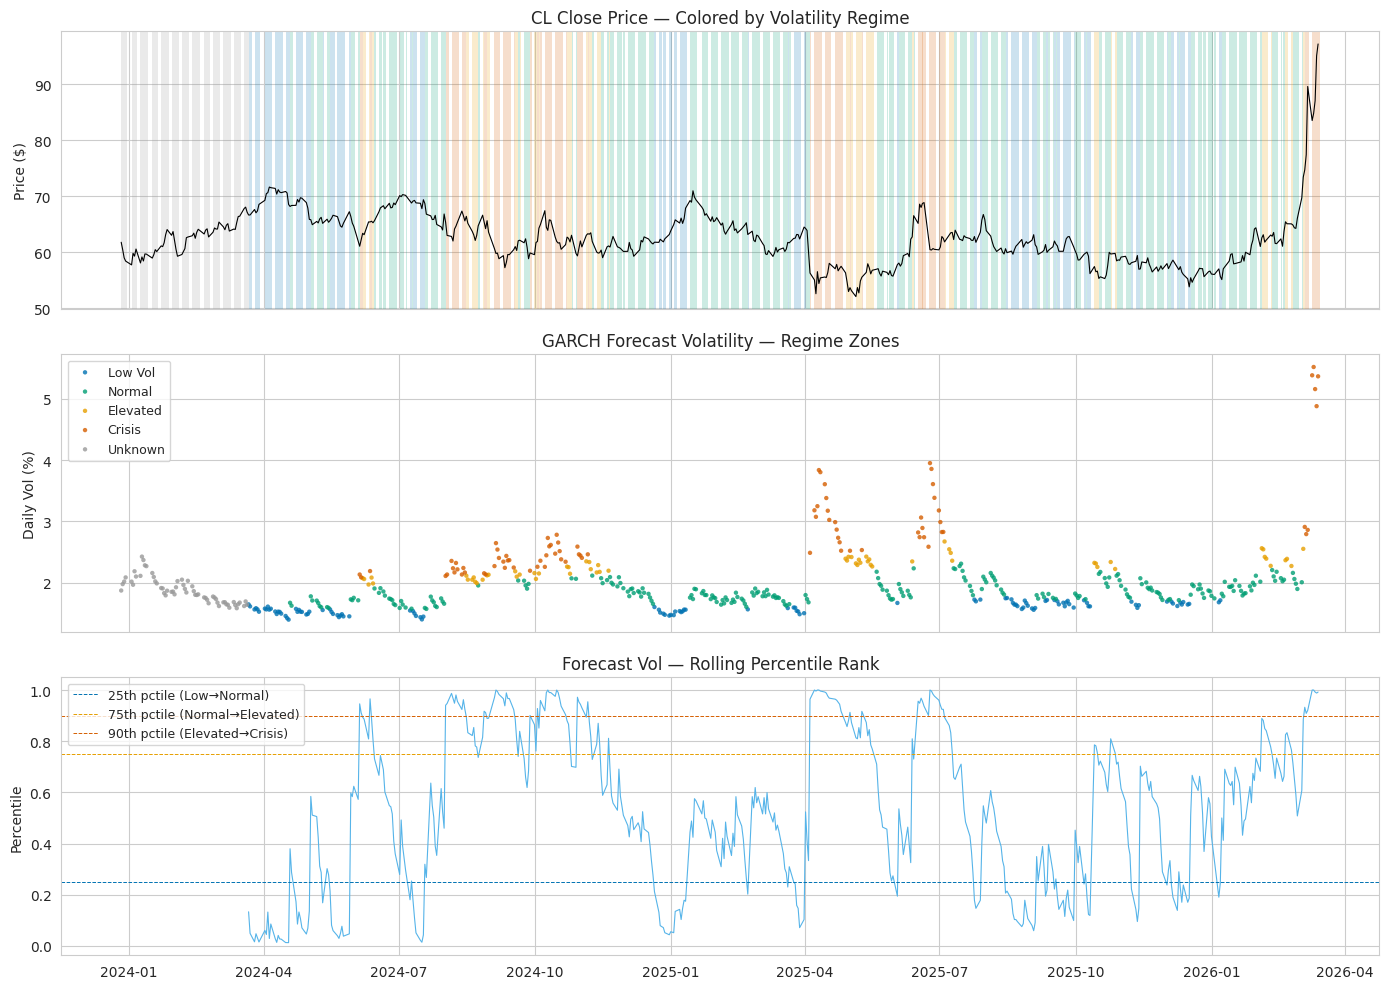

In [ ]:
# 7b) Visualize regimes overlaid on price and forecast vol
# Wong colorblind-safe palette
regime_colors = {
    'Low Vol':   '#0072B2',  # blue
    'Normal':    '#009E73',  # bluish green
    'Elevated':  '#E69F00',  # orange
    'Crisis':    '#D55E00',  # vermillion
    'Unknown':   '#999999',  # grey
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Price with regime background
test_close = df['close'].loc[test.index]
axes[0].plot(test_close.index, test_close.values, color='black', linewidth=0.8)
axes[0].set_title('CL Close Price -- Colored by Volatility Regime')
axes[0].set_ylabel('Price ($)')

# Shade regimes on price chart
for r, color in regime_colors.items():
    mask = regime == r
    if mask.any():
        for idx in mask[mask].index:
            if idx in test_close.index:
                axes[0].axvspan(idx, idx + pd.Timedelta(days=1), alpha=0.2, color=color, lw=0)

# Forecast vol with regime coloring
axes[1].set_title('GARCH Forecast Volatility -- Regime Zones')
axes[1].set_ylabel('Daily Vol (%)')
for r, color in regime_colors.items():
    mask = regime == r
    if mask.any():
        axes[1].scatter(forecast_vol[mask].index, forecast_vol[mask].values,
                       s=10, color=color, label=r, alpha=0.8, edgecolors='none')
axes[1].legend(loc='upper left', fontsize=9)

# Percentile rank over time
axes[2].plot(forecast_vol_rank.index, forecast_vol_rank.values, color='#56B4E9', linewidth=0.8)
axes[2].axhline(0.25, color='#0072B2', linestyle='--', linewidth=0.7, label='25th pctile (Low->Normal)')
axes[2].axhline(0.75, color='#E69F00', linestyle='--', linewidth=0.7, label='75th pctile (Normal->Elevated)')
axes[2].axhline(0.90, color='#D55E00', linestyle='--', linewidth=0.7, label='90th pctile (Elevated->Crisis)')
axes[2].set_title('Forecast Vol -- Rolling Percentile Rank')
axes[2].set_ylabel('Percentile')
axes[2].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# 7c) Return characteristics per regime
regime_stats = pd.DataFrame({
    'regime': regime,
    'return_pct': test,
    'abs_return': test.abs(),
    'forecast_vol': forecast_vol,
    'realized_var': test ** 2
}).dropna()
regime_stats = regime_stats[regime_stats['regime'] != 'Unknown']

# Stats by regime
summary = regime_stats.groupby('regime').agg(
    days=('return_pct', 'count'),
    mean_return=('return_pct', 'mean'),
    std_return=('return_pct', 'std'),
    mean_abs_return=('abs_return', 'mean'),
    mean_forecast_vol=('forecast_vol', 'mean'),
    sharpe_daily=('return_pct', lambda x: x.mean() / x.std() if x.std() > 0 else 0),
    max_drawdown_day=('return_pct', 'min'),
).round(4)

print("=== Return Characteristics by Volatility Regime ===")
print(summary.to_string())
print(f"\n-> Key insight: Compare mean return & Sharpe across regimes to decide when to trade")

=== Return Characteristics by Volatility Regime ===
          days  mean_return  std_return  mean_abs_return  mean_forecast_vol  sharpe_daily  max_drawdown_day
regime                                                                                                     
Crisis      83       0.1119      3.2790           2.2392             2.8159        0.0341           -9.6486
Elevated    62       0.3273      1.9758           1.5931             2.2637        0.1656           -3.2446
Low Vol    115       0.0856      1.6021           1.2793             1.5839        0.0534           -5.3849
Normal     246      -0.0101      1.7538           1.3319             1.8613       -0.0058           -5.9715

→ Key insight: Compare mean return & Sharpe across regimes to decide when to trade
